EXPERIMENT - 3

Predicting Stock Prices: Develop a time series prediction model to
forecast stock prices.

In [ ]:
# ==========================================
# STOCK PRICE PREDICTION USING TIME SERIES
# ==========================================

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


This code imports the required libraries to handle stock market data (pandas, numpy), visualize trends (matplotlib), build a Linear Regression model, evaluate its accuracy (MAE, MSE, R²), and save the trained model using pickle.

In [ ]:
# ==========================================
# STEP 1 — LOAD DATASET
# ==========================================

data = pd.read_csv("/content/drive/MyDrive/ML LAB EXPERIMENTS/stock_price_with_price_column.csv")

print(data.head())
print("\nDataset Info:\n")
print(data.info())


         Date Stock    Open    High     Low   Close   Volume       Price
0  2020-01-01  AAPL  173.80  174.75  173.68  174.43  8204212  174.286667
1  2020-01-02  AAPL  176.01  177.59  174.07  177.55  2766891  176.403333
2  2020-01-03  AAPL  177.57  178.37  176.62  176.71  5721339  177.233333
3  2020-01-06  AAPL  176.01  177.58  171.33  171.73  9242680  173.546667
4  2020-01-07  AAPL  171.85  172.20  170.69  170.82  4416664  171.236667

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6525 entries, 0 to 6524
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6525 non-null   object 
 1   Stock   6525 non-null   object 
 2   Open    6525 non-null   float64
 3   High    6525 non-null   float64
 4   Low     6525 non-null   float64
 5   Close   6525 non-null   float64
 6   Volume  6525 non-null   int64  
 7   Price   6525 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 407.9+ KB
None


This code loads the stock price dataset from a CSV file into a pandas DataFrame and displays the first few rows along with detailed information about columns, data types, and missing values.

In [ ]:
# ==========================================
# STEP 2 — DATA PREPROCESSING
# ==========================================

# Convert Date column to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Sort data by date (VERY IMPORTANT for time series)
data = data.sort_values("Date")

# Create lag feature (previous day's price)
data["Price_Lag_1"] = data["Price"].shift(1)

# Drop missing value created by lag
data = data.dropna()

# Features and target
X = data[["Price_Lag_1"]]
y = data["Price"]

This code converts the Date column to datetime format, sorts the data in chronological order, creates a lag feature using the previous day’s price, removes missing values caused by shifting, and separates input features (X) and target variable (y) for prediction.

In [ ]:
# ==========================================
# STEP 3 — DATA SPLIT (TIME-BASED)
# ==========================================

split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


This code splits the time series data chronologically, using the first 80% of records for training and the remaining 20% for testing, ensuring future data is not used to predict the past.

In [ ]:
# ==========================================
# STEP 4 — MODEL TRAINING
# ==========================================

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

This code initializes a Linear Regression model and trains it on the time-based training data to learn the relationship between past prices and current stock prices.

In [ ]:
# ==========================================
# STEP 5 — SAVE MODEL USING PICKLE
# ==========================================

with open("/content/drive/MyDrive/ML LAB EXPERIMENTS/stock_price_with_price_column.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")


Model saved successfully!


This code saves the trained stock price prediction model into a .pkl file using pickle, allowing it to be reused later without retraining.

In [ ]:
# ==========================================
# STEP 6 — MODEL EVALUATION
# ==========================================

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== Model Performance =====")
print("MSE :", mse)
print("R2 Score:", r2)



===== Model Performance =====
MSE : 570.4019751784713
R2 Score: 0.006835287564247339


This code predicts stock prices on the test data and evaluates model performance using MSE, and R² score to measure prediction accuracy and goodness of fit.

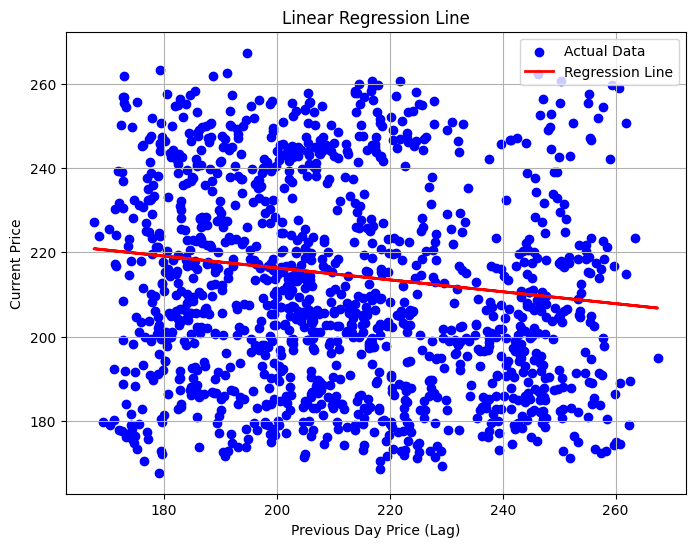

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Previous Day Price (Lag)")
plt.ylabel("Current Price")
plt.title("Linear Regression Line")

plt.legend()
plt.grid(True)
plt.show()


This code plots a line graph comparing actual stock prices with predicted prices over time, allowing you to visually assess how closely the model follows real market trends.